# Understanding the Ref FASTA 

In [8]:
import gzip
import os

# Define paths for the files you want to inspect
target_files = ["../data/reference/Sus_scrofa.Sscrofa11.1.cdna.all.fa.gz"]

for target_file in target_files:
    filename = os.path.basename(target_file)
    open_fn = gzip.open if target_file.endswith(".gz") else open

    first_5_lines = []
    total_lines = 0
    max_line_length = 0
    transcript_count = 0
    unique_genes = set()  # Set to track distinct gene IDs

    # Stream through the file to gather shape metrics and preview lines
    with open_fn(target_file, "rt") as handle:
        for line in handle:
            total_lines += 1
            clean_line = line.rstrip("\r\n")

            # Track Transcripts and Genes from header lines
            if line.startswith(">"):
                transcript_count += 1

                # Find and extract the 'gene:...' field
                for part in line.split():
                    if part.startswith("gene:"):
                        gene_id = part.split(":", 1)[1]
                        unique_genes.add(gene_id)
                        break

            # Store the first 5 lines
            if len(first_5_lines) < 5:
                first_5_lines.append(clean_line)

            # Track maximum line length (columns)
            if len(clean_line) > max_line_length:
                max_line_length = len(clean_line)

    # Print header, shape, metrics, and preview
    print(f"\n{'='*10} File: {filename} {'='*10}")
    print(
        f"Shape (Total Lines, Max Width): ({total_lines:,}, {max_line_length:,})"
    )
    print(f"Total Unique Transcripts: {transcript_count:,}")
    print(f"Total Unique Genes:       {len(unique_genes):,}")
    print("-" * 40)
    print("First 5 lines:")
    for line in first_5_lines:
        print(line)


========== File: Sus_scrofa.Sscrofa11.1.cdna.all.fa.gz ==========
Shape (Total Lines, Max Width): (2,487,484, 357)
Total Unique Transcripts: 46,369
Total Unique Genes:       22,516
----------------------------------------
First 5 lines:
>ENSSSCT00000002339.4 cdna primary_assembly:Sscrofa11.1:AEMK02000555.1:34878:35168:1 gene:ENSSSCG00000035087.2 gene_biotype:TR_V_gene transcript_biotype:TR_V_gene
AAACAGCATGTGAATCAGAGCCACGAAGCCCTGAGCGTCCGAGAGGGAGACGGCTTGGTT
CTCAACTGCAGTTACACCGATAGCGCTATTTACTTCCTTCAGTGGTTTAGGCAGTATCCT
GGGAAAGGGCTTACTTCTCTGCTGTTAATTCAAGCGAACCAGGGAGAACAAATAAGTGGA
AGAATTAAAGCCTCATTGGATAAATCGTCAAGAAACAGTGTTTTCTACATTGCAGCATCT


# Inspecting dmd_splicing_matrix.csv

In [9]:
import pandas as pd

# Load the dataset and display the first 10 rows
# Note: Set index_col=0 if the first column contains exon/sample IDs rather than data
df = pd.read_csv('../data/processed/splicing_matrix.csv')
df.head(5)

,Transcript_ID,SRR32086846,SRR32086848,SRR32086850,SRR32086830,SRR32086832,SRR32086836,mean_TPM_WT,mean_TPM_DMD,fold_change,Gene_ID,IF_DMD,IF_WT,Gene_Name
0,ENSSSCT00000019660,562.342977,459.901549,410.499472,444.081637,639.670911,448.405534,477.581333,510.719361,1.069386,ENSSSCG00000018065,1.0,1.0,ND1
1,ENSSSCT00000019664,353.471098,294.663002,317.050255,566.155260,472.968795,613.225246,321.728118,550.783100,1.711930,ENSSSCG00000018069,1.0,1.0,ND2
2,ENSSSCT00000019670,492.417681,485.020705,523.073988,1550.417623,1507.943906,1685.700721,500.170791,1581.354083,3.161585,ENSSSCG00000018075,1.0,1.0,COX1
3,ENSSSCT00000019673,1501.266861,1234.910440,1333.636342,3458.803243,3080.935513,3808.535173,1356.604548,3449.424643,2.542678,ENSSSCG00000018078,1.0,1.0,COX2
4,ENSSSCT00000019675,4750.440351,4860.873425,3835.651857,11075.955685,5320.894984,15203.767630,4482.321878,10533.539433,2.350016,ENSSSCG00000018080,1.0,1.0,ATP8


# Calculating a Summary Table for the splicing_matrix.csv

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configure plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

# Load dataset
df = pd.read_csv('../data/processed/splicing_matrix.csv')

# Quick metric check
print("Dataset dimensions:", df.shape)
df[["mean_TPM_WT", "mean_TPM_DMD", "fold_change", "IF_DMD","IF_WT"]].describe()

Dataset dimensions: (19700, 14)


,mean_TPM_WT,mean_TPM_DMD,fold_change,IF_DMD,IF_WT
count,19700.000000,19700.000000,19700.000000,19700.000000,19700.000000
mean,50.757934,50.758485,17.467977,0.647588,0.651891
std,1462.642296,1467.472266,342.754402,0.410230,0.408809
min,0.000000,0.000000,0.000144,0.000000,0.000000
25%,0.283807,0.279550,0.529672,0.197894,0.206571
50%,1.209885,1.245912,1.055800,0.935540,0.941983
75%,4.978635,5.395528,2.005854,0.999993,0.999993
max,143393.188954,146753.071718,41445.132900,1.000000,1.000000


In [11]:
# Check total rows vs unique Transcript IDs
total_rows = len(df)
unique_transcripts = df["Transcript_ID"].nunique()

print(f"Total rows: {total_rows}")
print(f"Unique Transcripts: {unique_transcripts}")

# Check how many unique GENES these transcripts belong to
unique_genes = df["Gene_ID"].nunique()
print(f"Belonging to {unique_genes} unique genes.")

Total rows: 19700
Unique Transcripts: 19700
Belonging to 13473 unique genes.


# Visualizing Isoform Fraction Data 

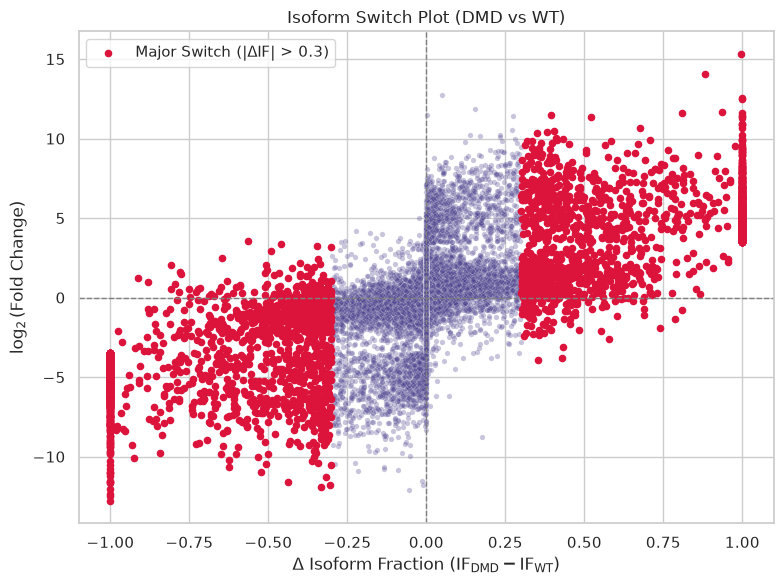

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Feature engineering
df["delta_IF"] = df["IF_DMD"] - df["IF_WT"]
df["log2_FC"] = np.log2(df["fold_change"])

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="delta_IF",
    y="log2_FC",
    alpha=0.3,
    s=15,
    color="darkslateblue"
)

# Highlight significant isoform switches (|delta_IF| > 0.3)
switches = df[df["delta_IF"].abs() > 0.3]
plt.scatter(switches["delta_IF"], switches["log2_FC"], color="crimson", s=20, label="Major Switch (|ΔIF| > 0.3)")

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Isoform Switch Plot (DMD vs WT)")
plt.xlabel(r"$\Delta$ Isoform Fraction ($\text{IF}_{\text{DMD}} - \text{IF}_{\text{WT}}$)")
plt.ylabel(r"$\log_2(\text{Fold Change})$")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

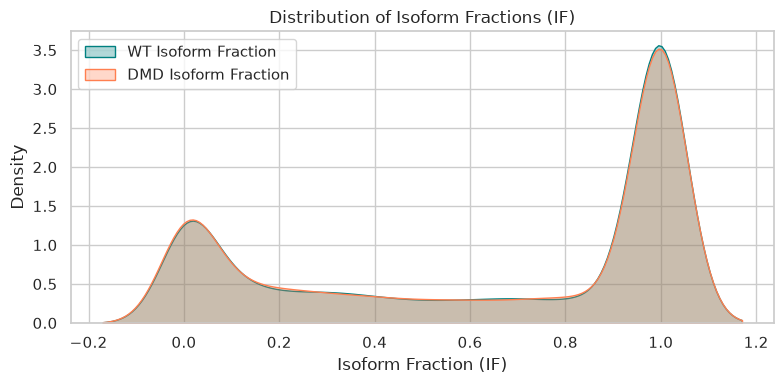

In [13]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df["IF_WT"], label="WT Isoform Fraction", color="teal", fill=True, alpha=0.3)
sns.kdeplot(df["IF_DMD"], label="DMD Isoform Fraction", color="coral", fill=True, alpha=0.3)

plt.title("Distribution of Isoform Fractions (IF)")
plt.xlabel("Isoform Fraction (IF)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# Concatenating  Gene Names into spliced matrix csv

In [14]:
import gzip
from pathlib import Path
import pandas as pd

# Load existing splicing matrix
df = pd.read_csv("../data/processed/splicing_matrix.csv")

# Extract Gene_ID -> Gene_Name map from FASTA
fasta_path = Path("../data/reference/Sus_scrofa.Sscrofa11.1.cdna.all.fa.gz")
gene_map = {}

with gzip.open(fasta_path, "rt") as handle:
    for line in handle:
        if line.startswith(">"):
            parts = line.strip().split()
            gene_id, gene_name = None, None

            for part in parts:
                if part.startswith("gene:"):
                    gene_id = part.split(":")[1].split(".")[0]
                elif part.startswith("gene_symbol:"):
                    gene_name = part.split(":")[1]

            if gene_id and gene_name:
                gene_map[gene_id] = gene_name

# Map names and fall back to Gene_ID if no symbol exists
df["Gene_Name"] = df["Gene_ID"].map(gene_map).fillna(df["Gene_ID"])

# Save updated CSV
df.to_csv("../data/processed/splicing_matrix.csv", index=False)
print(f"Mapped {df['Gene_Name'].nunique()} unique gene names.")
df[["Transcript_ID", "Gene_ID", "Gene_Name", "IF_DMD","IF_WT"]].head()

Mapped 13473 unique gene names.


,Transcript_ID,Gene_ID,Gene_Name,IF_DMD,IF_WT
0,ENSSSCT00000019660,ENSSSCG00000018065,ND1,1.0,1.0
1,ENSSSCT00000019664,ENSSSCG00000018069,ND2,1.0,1.0
2,ENSSSCT00000019670,ENSSSCG00000018075,COX1,1.0,1.0
3,ENSSSCT00000019673,ENSSSCG00000018078,COX2,1.0,1.0
4,ENSSSCT00000019675,ENSSSCG00000018080,ATP8,1.0,1.0


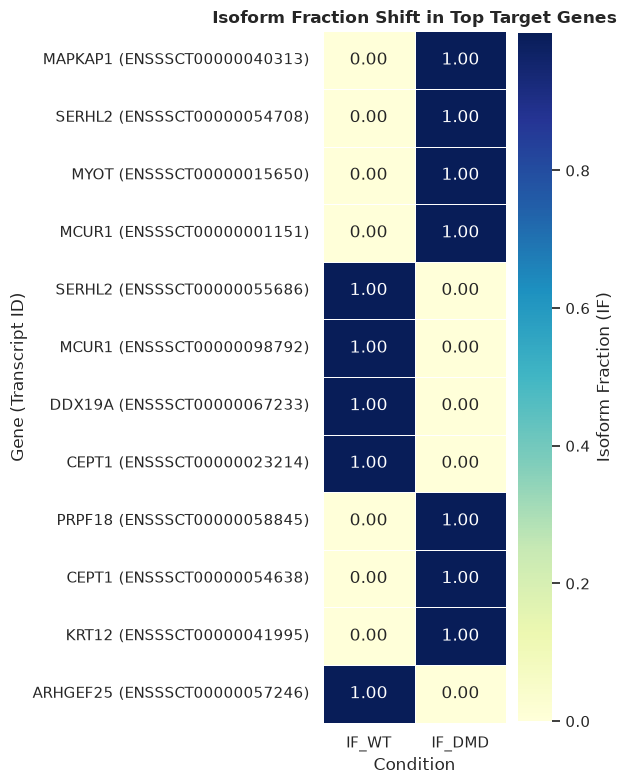

In [15]:
# Calculate maximum expression across conditions
df['max_TPM'] = df[['mean_TPM_WT', 'mean_TPM_DMD']].max(axis=1)

# Calculate change in Isoform Fraction
df['delta_IF'] = df['IF_DMD'] - df['IF_WT']
# Pick top 8 multi-isoform genes with highest isoform shifts
multi_genes = df['Gene_ID'].value_counts()
multi_genes = multi_genes[multi_genes >= 2].index

candidate_txs = (
    df[(df['Gene_ID'].isin(multi_genes)) & (df['max_TPM'] >= 1.0)]
    .sort_values(by="delta_IF", key=abs, ascending=False)
    .head(12)
)

# Prepare label: "Gene_Name - Transcript_ID"
candidate_txs["Label"] = candidate_txs["Gene_Name"] + " (" + candidate_txs["Transcript_ID"] + ")"
heatmap_data = candidate_txs.set_index("Label")[["IF_WT", "IF_DMD"]]

plt.figure(figsize=(6, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Isoform Fraction (IF)'},
    linewidths=0.5
)

plt.title("Isoform Fraction Shift in Top Target Genes", fontsize=12, fontweight="bold")
plt.ylabel("Gene (Transcript ID)")
plt.xlabel("Condition")
plt.tight_layout()
plt.show()

In [17]:
# Identify replicate IF columns
from config import DMD_RUNS, WT_RUNS

wt_if_cols = [f"IF_{sra}" for sra in WT_RUNS]
dmd_if_cols = [f"IF_{sra}" for sra in DMD_RUNS]
all_if_cols = wt_if_cols + dmd_if_cols

# Filter for top 12 statistically significant switches sorted by FDR
top_sig = (
    df[(df["FDR"] < 0.05) & (df["delta_IF"].abs() > 0.2)]
    .sort_values(by="FDR")
    .head(12)
    .copy()
)

# Create display label
if "Gene_Name" in top_sig.columns:
    top_sig["Label"] = (
        top_sig["Gene_Name"] + " (" + top_sig["Transcript_ID"] + ")"
    )
else:
    top_sig["Label"] = top_sig["Transcript_ID"]

heatmap_df = top_sig.set_index("Label")[all_if_cols]

# Plot Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    xticklabels=[
        "WT_Rep2",
        "WT_Rep3",
        "WT_Rep4",
        "DMD_Rep1",
        "DMD_Rep3",
        "DMD_Rep4",
    ],
)

plt.title(
    "Per-Replicate Isoform Fraction Consistency (Top Significant Switches)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Sample Replicates")
plt.ylabel("Gene (Transcript ID)")
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'config'

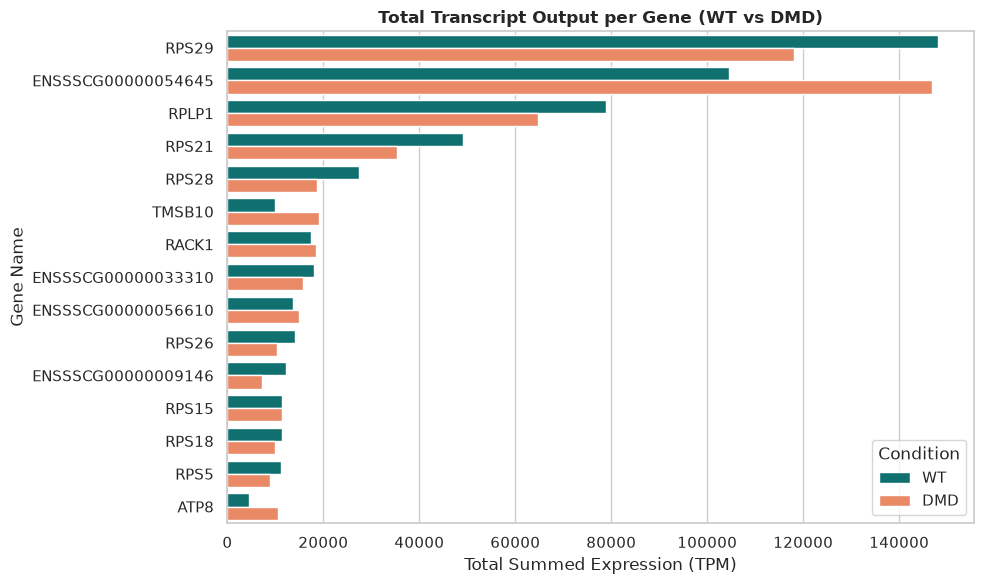

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load data
df = pd.read_csv("../data/processed/splicing_matrix.csv")

# 1. Aggregate transcript TPMs to get Total Gene Output per condition
gene_summary = (
    df.groupby(["Gene_ID", "Gene_Name"])[["mean_TPM_WT", "mean_TPM_DMD"]]
    .sum()
    .reset_index()
)

# Compute max total TPM to filter top expressed genes
gene_summary["max_total_TPM"] = gene_summary[["mean_TPM_WT", "mean_TPM_DMD"]].max(axis=1)

# Pick top 15 most highly expressed genes (or top switching genes)
top_genes = gene_summary.nlargest(15, "max_total_TPM")

# 2. Reshape (Melt) for color-coded plotting
plot_df = top_genes.melt(
    id_vars=["Gene_Name"],
    value_vars=["mean_TPM_WT", "mean_TPM_DMD"],
    var_name="Condition",
    value_name="Total_Gene_TPM",
)
plot_df["Condition"] = plot_df["Condition"].map(
    {"mean_TPM_WT": "WT", "mean_TPM_DMD": "DMD"}
)

# 3. Grouped Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x="Total_Gene_TPM",
    y="Gene_Name",
    hue="Condition",
    palette={"WT": "teal", "DMD": "coral"},
)

plt.title("Total Transcript Output per Gene (WT vs DMD)", fontsize=12, fontweight="bold")
plt.xlabel("Total Summed Expression (TPM)")
plt.ylabel("Gene Name")
plt.legend(title="Condition")
plt.tight_layout()
plt.show()

# Obtaining Gene information per id 

In [8]:
"""import gzip
from pathlib import Path
import mygene
import pandas as pd

# Step 1: Read unique Gene_IDs from the splicing matrix
print("[1/4] Extracting unique Gene IDs from matrix...")
matrix_path = Path("../data/processed/splicing_matrix.csv")
df = pd.read_csv(matrix_path, usecols=["Gene_ID"])
unique_gene_ids = df["Gene_ID"].dropna().unique().tolist()

# Step 2: Extract Gene_ID -> Gene_Name map from FASTA
fasta_path = Path("../data/reference/Sus_scrofa.Sscrofa11.1.cdna.all.fa.gz")
gene_map = {}

print(f"[2/4] Parsing FASTA ({fasta_path.name})... Please wait ~30-60 seconds.")
line_count = 0
with gzip.open(fasta_path, "rt") as handle:
    for line in handle:
        line_count += 1
        if line_count % 1000000 == 0:
            print(f"      ...processed {line_count:,} lines...")

        if line.startswith(">"):
            parts = line.strip().split()
            gene_id, gene_name = None, None

            for part in parts:
                if part.startswith("gene:"):
                    gene_id = part.split(":")[1].split(".")[0]
                elif part.startswith("gene_symbol:"):
                    gene_name = part.split(":")[1]

            if gene_id and gene_name:
                gene_map[gene_id] = gene_name

print(f"      [✓] Mapped {len(gene_map):,} gene IDs from FASTA.")

# Create base mapping DataFrame for dataset genes
mapping_df = pd.DataFrame({"Gene_ID": unique_gene_ids})
mapping_df["Gene_Name"] = mapping_df["Gene_ID"].map(gene_map).fillna(
    mapping_df["Gene_ID"]
)

# Step 3: Query MyGene using built-in batching
unique_genes_to_query = mapping_df["Gene_Name"].unique().tolist()
print(
    f"[3/4] Querying MyGene.info for {len(unique_genes_to_query):,} unique genes..."
)

mg = mygene.MyGeneInfo()
results = mg.querymany(
    unique_genes_to_query,
    scopes=["symbol", "ensembl.gene"],
    fields=["name", "summary", "go.BP"],
    species="pig,human",
    step=1000,
    as_dataframe=False,
)

# Step 4: Parse MyGene API responses & Save Mapping CSV
print("[4/4] Parsing functional terms & saving standalone gene mapping file...")
annotations = {}
for res in results:
    query_key = res.get("query")
    if not query_key or query_key in annotations:
        continue

    full_description = res.get("name", None)
    summary = res.get("summary", None)

    go_bp_list = []
    go_data = (
        res.get("go", {}).get("BP", [])
        if isinstance(res.get("go"), dict)
        else []
    )

    if isinstance(go_data, dict):
        go_data = [go_data]

    for term in go_data:
        if isinstance(term, dict) and "term" in term:
            go_bp_list.append(term["term"])

    go_bp_str = "; ".join(list(set(go_bp_list))[:5]) if go_bp_list else None

    annotations[query_key] = {
        "Gene_Description": full_description,
        "Gene_Summary": summary,
        "GO_Biological_Process": go_bp_str,
    }

anno_df = pd.DataFrame.from_dict(annotations, orient="index").reset_index()
anno_df.rename(columns={"index": "Gene_Name"}, inplace=True)

# Merge annotations into mapping lookup table
mapping_full = mapping_df.merge(anno_df, on="Gene_Name", how="left")

# Save dedicated gene mapping CSV
map_output_path = Path("../data/processed/gene_id_to_name_mapping.csv")
mapping_full.to_csv(map_output_path, index=False)

print(f"[✓] Done! Gene lookup table saved to: {map_output_path}")"""

[1/4] Extracting unique Gene IDs from matrix...
[2/4] Parsing FASTA (Sus_scrofa.Sscrofa11.1.cdna.all.fa.gz)... Please wait ~30-60 seconds.
      ...processed 1,000,000 lines...
      ...processed 2,000,000 lines...
      [✓] Mapped 15,815 gene IDs from FASTA.
[3/4] Querying MyGene.info for 13,473 unique genes...


11282 input query terms found dup hits:	[('SH3YL1', 2), ('FAM110C', 2), ('EDIL3', 2), ('COX7C', 2), ('CETN3', 2), ('MBLAC2', 2), ('LYSMD3', 
126 input query terms found no hit:	['C12orf29', 'C12orf50', 'MFSD3', 'ENSSSCG00000005901', 'ENSSSCG00000053412', 'MDM1', 'BVES', 'MFSD9


[4/4] Parsing functional terms & saving standalone gene mapping file...
[✓] Done! Gene lookup table saved to: ../data/processed/gene_id_to_name_mapping.csv
